In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM
from Equipments.MCBOX import generate_test_voltages

from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('TCPIP0::K-34465A-15333::hislip0::INSTR', 'TCPIP0::K-34465A-15333::inst0::INSTR', 'ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [4]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


In [5]:
bias_channel = 11

In [ ]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 1.2, bipolar = True, display = True) # changed from 2.8 V

In [6]:
agilent = Agilent.Agilent('TCPIP0::169.254.110.10::inst0::INSTR',power_limit = 0, freq_limit = 40e9)

Agilent Technologies, N5183A, MY47420242, A.01.43



In [7]:
pm = ThorlabsPM.ThorlabsPM('USB0::0x1313::0x807B::241023118::0::INSTR')

Thorlabs,PM16-130,241023118,1.6.0



## 700MHz

In [ ]:
agilent.set_frequency(frequency = 0.7e9)

output_power = []
RF_power_list = np.linspace(-30, 0, 31) # [dBm]
bias_list = np.linspace(-4,7,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power}dBm")
    agilent.set_power(RF_power)
    time.sleep(1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064,average=50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

In [ ]:
ps.Plot3D(x = RF_power_list+30, y = bias_list, Z = np.array(output_power),
          xlabel = "RF power after Amp (dBm) @ 700MHz", ylabel = "DC bias (V)", zlabel = "Output Power (W)",transpose=True)  

## 38GHz

RF_list_top = np.linspace(-14.5,-5,50)
RF_list_bot = np.linspace(-35,-15,20)
RF_power_list = np.concatenate((RF_list_bot,RF_list_top), axis=0)
print(RF_power_list)

In [8]:
output_power = []
#RF_power_list = np.linspace(-35,-5,39) # [dBm]
RF_list_top = np.linspace(-14.5,-5,50)
RF_list_bot = np.linspace(-35,-15,20)
RF_power_list = np.concatenate((RF_list_bot,RF_list_top), axis=0)

bias_list = np.linspace(-5,5,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_frequency(frequency = 38.0e9)  # changed from 10 GHz
agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power} dBm")
    agilent.set_power(RF_power)
    time.sleep(0.1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064, average = 50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

[-35.         -33.94736842 -32.89473684 -31.84210526 -30.78947368
 -29.73684211 -28.68421053 -27.63157895 -26.57894737 -25.52631579
 -24.47368421 -23.42105263 -22.36842105 -21.31578947 -20.26315789
 -19.21052632 -18.15789474 -17.10526316 -16.05263158 -15.
 -14.5        -14.30612245 -14.1122449  -13.91836735 -13.7244898
 -13.53061224 -13.33673469 -13.14285714 -12.94897959 -12.75510204
 -12.56122449 -12.36734694 -12.17346939 -11.97959184 -11.78571429
 -11.59183673 -11.39795918 -11.20408163 -11.01020408 -10.81632653
 -10.62244898 -10.42857143 -10.23469388 -10.04081633  -9.84693878
  -9.65306122  -9.45918367  -9.26530612  -9.07142857  -8.87755102
  -8.68367347  -8.48979592  -8.29591837  -8.10204082  -7.90816327
  -7.71428571  -7.52040816  -7.32653061  -7.13265306  -6.93877551
  -6.74489796  -6.55102041  -6.35714286  -6.16326531  -5.96938776
  -5.7755102   -5.58163265  -5.3877551   -5.19387755  -5.        ]
[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.7

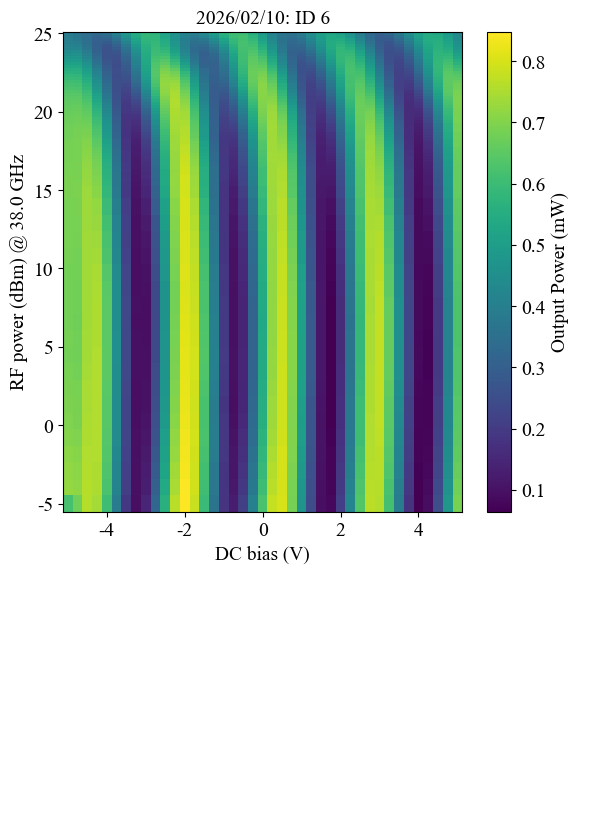

In [10]:
ps.Plot3D(x = RF_power_list + 30, y = bias_list, Z = np.array(output_power)*1e+3,
          xlabel = "RF power (dBm) @ 38.0 GHz", ylabel = "DC bias (V)", zlabel = "Output Power (mW)", transpose = True)  

In [11]:
pm.close()

In [12]:
agilent.close()

In [13]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

Channel 11 has been set to 0 V.


In [14]:
rm.list_opened_resources()

[]

In [15]:
rm.close()

## Check the polarization

In [ ]:
def func(x,a,b,c,d):
    return a*np.sin(b*x+c)+d

In [ ]:
bias_list = np.linspace(-9,9,41) # [V]
transmission = []

for bias in bias_list:
    mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
    power = pm.readout(wavelength = 1064,average=50)
    transmission.append(power)
    

In [ ]:
popt1, pcov1 = curve_fit(
            func, bias_list, transmission,maxfev=10000000,
        )

plt.figure()
plt.scatter(bias_list,np.array(transmission),c = "r",label = "measurement")
plt.plot(bias_list,func(bias_list,*popt1), label = "fitted curve")
plt.xlabel('bias voltage (V)')
plt.ylabel("transmission")
plt.title(f"DC v_pi = {np.pi/popt1[1]}")
plt.legend()
plt.show()

In [ ]:
ps.Plot2D(x = bias_list, y = None, Z=transmission, xlabel='bias (V)', ylabel='Y', zlabel='transmission')


## test the degrade for RF

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
transimission_intensity = np.array([5.8,])
voltage = np.array([-4,-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,])

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
def func(x,a,b,c):
    return a*np.sin(b*x)+c

popt1, pcov1 = curve_fit(
            func, voltage, transimission_intensity,maxfev=100000,
        )

In [ ]:
popt1

In [ ]:
plt.plot(voltage, func(voltage,*popt1))